# Notebook 03: Image Preprocessing

---

## Overview

This notebook prepares the NIH Chest X-Ray images for deep learning model training.

**Objectives:**
1. Load and inspect image data
2. Implement image resizing and normalization
3. Create stratified train/validation/test splits
4. Set up data augmentation pipeline with **reusable transformers**
5. Handle class imbalance
6. Create efficient data generators for training

**Outputs:**
- Train/val/test split files
- Reusable preprocessing pipeline
- Preprocessing configuration
- Sample augmented images

---

## 💡 Why Not feature_engine?

`feature_engine` is an excellent library for **tabular data preprocessing** (handling missing values, categorical encoding, outlier treatment, etc.). However, it is **NOT designed for image data**.

For images, we need specialized operations:
- Image loading and format conversion
- Resizing and augmentation (rotation, flipping, noise)
- Pixel normalization for deep learning

### Our Approach: sklearn-style Image Transformers

We follow the same **design patterns** as `feature_engine` and `sklearn`:
- Custom transformers with `fit()` / `transform()` methods
- Composable `Pipeline` architecture
- Reusable, testable, maintainable code
- Easy serialization for deployment

This demonstrates **good software engineering** while using the right tools for computer vision tasks.

### Pipeline Architecture

```
Input: Image file paths
    ↓
┌─────────────────────────┐
│  1. ImageLoader         │  Load images from disk
└─────────────────────────┘
    ↓
┌─────────────────────────┐
│  2. GrayscaleToRGB      │  Convert to 3-channel RGB
└─────────────────────────┘
    ↓
┌─────────────────────────┐
│  3. ImageResizer        │  Resize to 224x224
└─────────────────────────┘
    ↓
┌─────────────────────────┐
│  4. ImageAugmenter      │  (Training only) Flip, rotate, noise
└─────────────────────────┘
    ↓
┌─────────────────────────┐
│  5. ImageNormalizer     │  ImageNet mean/std normalization
└─────────────────────────┘
    ↓
Output: Preprocessed numpy arrays ready for model training
```

**Benefits:**
- ✅ Modular and testable components
- ✅ Easy to swap preprocessing strategies
- ✅ Reusable across notebooks and production code
- ✅ Consistent with sklearn/feature_engine patterns

---

## 1. Setup and Configuration

In [1]:
# Import libraries
import json
import sys
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Image processing
import albumentations as A
from PIL import Image

# Deep learning
import tensorflow as tf

# ML utilities
from sklearn.model_selection import train_test_split

# Configuration
warnings.filterwarnings('ignore')

# Import our custom preprocessing pipeline
sys.path.append(str(Path.cwd().parent / 'src'))

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU'))} GPUs")
print("\n✅ Custom preprocessing pipeline imported from src/preprocessing/")

✓ Libraries imported successfully
TensorFlow version: 2.18.1
GPU available: 0 GPUs

✅ Custom preprocessing pipeline imported from src/preprocessing/


In [2]:
# Define paths - robust project root detection
from pathlib import Path

# Find project root (where setup.py or README.md exists)
current_path = Path.cwd()

# Check if we're in jupyter_notebooks directory
if current_path.name == 'jupyter_notebooks':
    PROJECT_ROOT = current_path.parent
# Check if we're already in project root (has setup.py or README.md)
elif (current_path / 'setup.py').exists() or (current_path / 'README.md').exists():
    PROJECT_ROOT = current_path
# Otherwise, assume we need to go up one level
else:
    PROJECT_ROOT = current_path.parent

DATA_DIR = PROJECT_ROOT / 'data'
RAW_DATA_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'

# Create processed data directory
PROCESSED_DIR.mkdir(exist_ok=True, parents=True)

print(f"Current working directory: {Path.cwd()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data: {RAW_DATA_DIR}")
print(f"Processed data: {PROCESSED_DIR}")

# Verify data directory exists
if not RAW_DATA_DIR.exists():
    raise FileNotFoundError(
        f"\n❌ Data directory not found: {RAW_DATA_DIR}\n"
        f"   Project root detected as: {PROJECT_ROOT}\n"
        f"   Current directory: {Path.cwd()}\n\n"
        f"   Please ensure:\n"
        f"   1. You're running this notebook from the jupyter_notebooks/ directory\n"
        f"   2. Or from the project root (CapStone/)\n"
        f"   3. The data has been downloaded (run Notebook 01 first)"
    )

Current working directory: /Users/james/CodeInstitute/CapStone
Project root: /Users/james/CodeInstitute/CapStone
Raw data: /Users/james/CodeInstitute/CapStone/data/raw
Processed data: /Users/james/CodeInstitute/CapStone/data/processed


In [3]:
# Preprocessing configuration
CONFIG = {
    # Image dimensions
    'img_height': 224,
    'img_width': 224,
    'channels': 3,  # RGB for transfer learning
    
    # Data splits
    'train_ratio': 0.70,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    
    # Training parameters
    'batch_size': 32,
    'num_classes': 14,  # Excluding "No Finding"
    
    # Normalization
    'pixel_scaling': 'imagenet',  # 'imagenet' or '0-1'
    
    # Random seed
    'random_state': 42
}

print("Preprocessing Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Preprocessing Configuration:
  img_height: 224
  img_width: 224
  channels: 3
  train_ratio: 0.7
  val_ratio: 0.15
  test_ratio: 0.15
  batch_size: 32
  num_classes: 14
  pixel_scaling: imagenet
  random_state: 42


## 2. Load Metadata and Image Paths

### 📚 What We're Doing

In traditional machine learning with tabular data (e.g., CSV files), we load data directly into a DataFrame and start working with features. **With images, it's different**: we have two separate pieces:

1. **Metadata** (CSV file): Contains labels, patient info, demographics - this is like our traditional DataFrame
2. **Image files** (PNG files): The actual pixel data - this is our "raw features" that need preprocessing

**Analogy to Tabular Data:**
- If you were predicting house prices, you'd load a CSV with features like `bedrooms`, `square_feet`, `location`
- Here, we're loading a CSV with features like `Patient Age`, `Patient Gender`, `Disease Labels` - BUT the main "feature" (the X-ray image) is stored in a separate file

**Why separate?** Images are HUGE (1024×1024 pixels = ~1 million numbers per image). Storing 112K images in a CSV would be impossible. Instead, we store:
- Lightweight metadata in CSV format
- Heavy image data in efficient PNG format
- Create a mapping between them using file paths

In [4]:
# Load metadata
metadata_df = pd.read_csv(RAW_DATA_DIR / 'Data_Entry_2017.csv')

print(f"✓ Loaded metadata: {len(metadata_df):,} images")
print(f"\nColumns: {list(metadata_df.columns)}")
metadata_df.head()

✓ Loaded metadata: 112,120 images

Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [5]:
# Find all image directories
parent_dirs = sorted([d for d in RAW_DATA_DIR.iterdir() if d.is_dir() and d.name.startswith('images_')])

image_dirs = []
for parent in parent_dirs:
    if list(parent.glob('*.png'))[:1]:
        image_dirs.append(parent)
    elif (parent / 'images').exists():
        image_dirs.append(parent / 'images')

# Build full path mapping
file_path_map = {}
for img_dir in image_dirs:
    for img_file in img_dir.glob('*.png'):
        file_path_map[img_file.name] = str(img_file)

print(f"✓ Found {len(image_dirs)} image directories")
print(f"✓ Mapped {len(file_path_map):,} image paths")

✓ Found 12 image directories
✓ Mapped 112,120 image paths


In [6]:
# Add full path to metadata
metadata_df['full_path'] = metadata_df['Image Index'].map(file_path_map)

# Check for missing files
missing_files = metadata_df['full_path'].isna().sum()
if missing_files > 0:
    print(f"⚠️ Warning: {missing_files:,} images in metadata not found on disk")
    metadata_df = metadata_df.dropna(subset=['full_path'])
    print(f"  Continuing with {len(metadata_df):,} images")
else:
    print(f"✓ All {len(metadata_df):,} images found")

✓ All 112,120 images found


## 3. Prepare Multi-Label Encoding

### 📚 What We're Doing

This is where image classification gets **more complex** than typical tabular classification problems.

**Three types of classification:**

1. **Binary Classification** (Logistic Regression):
   - Examples: Spam/Not Spam, Fraud/Not Fraud, Sick/Healthy
   - **One** output: probability of being in class 1
   - Loss function: Binary Cross-Entropy

2. **Multiclass Classification**:
   - Examples: Iris species (Setosa/Versicolor/Virginica), Digit recognition (0-9)
   - **One** output per class, but **only ONE can be true**
   - Use one-hot encoding: `[0, 1, 0]` means class 2
   - Loss function: Categorical Cross-Entropy

3. **Multi-Label Classification** (Our case):
   - Examples: Movie genres (a film can be Action AND Comedy), Medical diagnoses
   - **Multiple outputs can be true simultaneously**
   - Each disease is an independent binary classification: `[1, 0, 1, 0, ...]`
   - An X-ray might show Cardiomegaly **AND** Effusion **AND** Edema together
   - Loss function: Binary Cross-Entropy (applied to each label independently)

**Real-world analogy:**
- **Multiclass**: A student can only graduate with ONE degree (Bachelor's OR Master's OR PhD)
- **Multi-label**: A person can have MULTIPLE skills (Python AND SQL AND Statistics)

In our dataset, a chest X-ray can show multiple diseases simultaneously - we need to predict **14 independent binary decisions**, not choose 1 out of 14 classes.

In [7]:
# Extract all unique disease labels
all_labels = metadata_df['Finding Labels'].str.split('|')
unique_diseases = sorted(set([label for labels in all_labels for label in labels]))

# Remove "No Finding" from classes (we'll treat this separately)
disease_classes = [d for d in unique_diseases if d != 'No Finding']

print(f"Disease classes for classification ({len(disease_classes)}):")
for i, disease in enumerate(disease_classes, 1):
    count = metadata_df['Finding Labels'].str.contains(disease, regex=False).sum()
    print(f"  {i:2d}. {disease:20s} - {count:,} images")

# Create binary encoding for each disease
for disease in disease_classes:
    metadata_df[disease] = metadata_df['Finding Labels'].str.contains(disease, regex=False).astype(int)

# Create a column for "No Finding"
metadata_df['No_Finding'] = metadata_df['Finding Labels'].apply(lambda x: 1 if x == 'No Finding' else 0)

print(f"\n✓ Created binary encodings for {len(disease_classes)} diseases")

Disease classes for classification (14):
   1. Atelectasis          - 11,559 images
   2. Cardiomegaly         - 2,776 images
   3. Consolidation        - 4,667 images
   4. Edema                - 2,303 images
   5. Effusion             - 13,317 images
   6. Emphysema            - 2,516 images
   7. Fibrosis             - 1,686 images
   8. Hernia               - 227 images
   9. Infiltration         - 19,894 images
  10. Mass                 - 5,782 images
  11. Nodule               - 6,331 images
  12. Pleural_Thickening   - 3,385 images
  13. Pneumonia            - 1,431 images
  14. Pneumothorax         - 5,302 images

✓ Created binary encodings for 14 diseases


## 4. Create Train/Validation/Test Splits

### 📚 What We're Doing

**Strategy**: Stratified split by patient ID to avoid data leakage (same patient's images should not appear in multiple sets)

This is similar to train/test splitting in tabular data, but with an **important medical imaging twist**.

**In tabular data:**
- Split rows randomly: 70% train, 15% validation, 15% test
- Each row is independent (usually)
- Use `train_test_split()` directly

**In medical imaging:**
- **Problem**: Same patient can have multiple X-rays over time (follow-up visits)
- **Risk**: If Patient 123's X-rays appear in BOTH training and test sets, the model might memorize that patient's unique anatomy rather than learning disease patterns
- **Solution**: Split by **patient ID**, not by image
  - All of Patient 123's X-rays go into training set
  - All of Patient 456's X-rays go into test set
  - No patient appears in multiple sets

**Real-world analogy:**
Imagine training a model to detect fraudulent credit card transactions:
- ❌ **Wrong**: Randomly split transactions (Customer A's transactions in both train and test)
- ✅ **Right**: Split by customer ID (Customer A's transactions only in training OR test, never both)

This prevents the model from "memorizing" individual customers/patients rather than learning general patterns.

**Why this matters:** Without patient-level splitting, we'd get artificially high test accuracy because the model has seen similar images from the same patients during training. This is called **data leakage** and gives false confidence in model performance.

In [8]:
# Get unique patient IDs
patient_ids = metadata_df['Patient ID'].unique()
print(f"Total unique patients: {len(patient_ids):,}")

# Split patients into train/val/test
train_patients, temp_patients = train_test_split(
    patient_ids, 
    test_size=(CONFIG['val_ratio'] + CONFIG['test_ratio']),
    random_state=CONFIG['random_state']
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=CONFIG['test_ratio'] / (CONFIG['val_ratio'] + CONFIG['test_ratio']),
    random_state=CONFIG['random_state']
)

# Create split dataframes
train_df = metadata_df[metadata_df['Patient ID'].isin(train_patients)].copy()
val_df = metadata_df[metadata_df['Patient ID'].isin(val_patients)].copy()
test_df = metadata_df[metadata_df['Patient ID'].isin(test_patients)].copy()

print("\n📊 Data Splits (by patient):")
print(f"  Train: {len(train_patients):,} patients ({len(train_patients)/len(patient_ids)*100:.1f}%)")
print(f"  Val:   {len(val_patients):,} patients ({len(val_patients)/len(patient_ids)*100:.1f}%)")
print(f"  Test:  {len(test_patients):,} patients ({len(test_patients)/len(patient_ids)*100:.1f}%)")

print("\n📊 Data Splits (by images):")
print(f"  Train: {len(train_df):,} images ({len(train_df)/len(metadata_df)*100:.1f}%)")
print(f"  Val:   {len(val_df):,} images ({len(val_df)/len(metadata_df)*100:.1f}%)")
print(f"  Test:  {len(test_df):,} images ({len(test_df)/len(metadata_df)*100:.1f}%)")

Total unique patients: 30,805

📊 Data Splits (by patient):
  Train: 21,563 patients (70.0%)
  Val:   4,621 patients (15.0%)
  Test:  4,621 patients (15.0%)

📊 Data Splits (by images):
  Train: 78,566 images (70.1%)
  Val:   17,063 images (15.2%)
  Test:  16,491 images (14.7%)


In [9]:
# Verify no patient overlap between sets
train_set = set(train_patients)
val_set = set(val_patients)
test_set = set(test_patients)

assert len(train_set & val_set) == 0, "Train and validation sets overlap!"
assert len(train_set & test_set) == 0, "Train and test sets overlap!"
assert len(val_set & test_set) == 0, "Validation and test sets overlap!"

print("✓ No patient overlap between train/val/test sets (data leakage prevented)")

✓ No patient overlap between train/val/test sets (data leakage prevented)


In [10]:
# Save split dataframes
train_df.to_csv(PROCESSED_DIR / 'train_split.csv', index=False)
val_df.to_csv(PROCESSED_DIR / 'val_split.csv', index=False)
test_df.to_csv(PROCESSED_DIR / 'test_split.csv', index=False)

print(f"✓ Saved split files to {PROCESSED_DIR}")
print(f"  - train_split.csv ({len(train_df):,} rows)")
print(f"  - val_split.csv ({len(val_df):,} rows)")
print(f"  - test_split.csv ({len(test_df):,} rows)")

✓ Saved split files to /Users/james/CodeInstitute/CapStone/data/processed
  - train_split.csv (78,566 rows)
  - val_split.csv (17,063 rows)
  - test_split.csv (16,491 rows)


## 5. Analyze Class Distribution in Splits

In [11]:
# Check disease distribution across splits
print("Disease distribution across splits:\n")
print(f"{'Disease':<20} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 50)

for disease in disease_classes:
    train_count = train_df[disease].sum()
    val_count = val_df[disease].sum()
    test_count = test_df[disease].sum()
    print(f"{disease:<20} {train_count:>8,} {val_count:>8,} {test_count:>8,}")

print("\n" + "-" * 50)
print(f"{'No Finding':<20} {train_df['No_Finding'].sum():>8,} {val_df['No_Finding'].sum():>8,} {test_df['No_Finding'].sum():>8,}")

Disease distribution across splits:

Disease                 Train      Val     Test
--------------------------------------------------
Atelectasis             8,190    1,692    1,677
Cardiomegaly            1,891      446      439
Consolidation           3,228      709      730
Edema                   1,630      299      374
Effusion                9,438    1,987    1,892
Emphysema               1,666      396      454
Fibrosis                1,156      259      271
Hernia                    158       42       27
Infiltration           13,868    3,094    2,932
Mass                    4,260      795      727
Nodule                  4,432      954      945
Pleural_Thickening      2,379      522      484
Pneumonia                 995      222      214
Pneumothorax            3,770      807      725

--------------------------------------------------
No Finding             42,210    9,242    8,909


## 6. Calculate Class Weights for Imbalanced Learning

### 📚 What We're Doing

**Class imbalance** is a universal problem in machine learning - whether you're working with tabular data or images!

**The problem:**
When one class has far fewer examples than others, the model becomes "lazy":
- It learns to always predict the majority class (gets high accuracy without learning anything useful)
- Minority classes get ignored

**Example from tabular data:**
Fraud detection dataset:
- 99,000 legitimate transactions (99%)
- 1,000 fraudulent transactions (1%)
- Model that always predicts "legitimate" achieves 99% accuracy but catches ZERO fraud! 🚨

**In our chest X-ray dataset:**
- Hernia: only **158 images** (0.2% of training data)
- Infiltration: **13,868 images** (17.7% of training data)
- Without correction, model would never learn to detect Hernia (too rare)

**Solution: Class Weights**

We tell the model: "Mistakes on rare classes are MORE important than mistakes on common classes"

**Weight formula:** `weight = n_negative / n_positive`

Example:
- Hernia: 158 positive, 78,408 negative → weight = **496.25** (VERY important to get right)
- Infiltration: 13,868 positive, 64,698 negative → weight = **4.67** (less critical)

**How it works in training:**
- Normal loss: All mistakes cost the same
- Weighted loss: Misclassifying rare Hernia costs **496× more** than common disease
- Model pays more attention to learning rare diseases

**Comparison to Logistic Regression:**
This is **exactly the same concept** as the `class_weight='balanced'` parameter in sklearn's LogisticRegression! The math is identical - we're just applying it to neural networks processing images instead of linear models processing tabular features.

In [12]:
# Calculate class weights for each disease
class_weights_dict = {}

print("Class weights (for handling imbalance):\n")
print(f"{'Disease':<20} {'Positive':>10} {'Weight':>10}")
print("-" * 45)

for i, disease in enumerate(disease_classes):
    # Count positive and negative samples
    n_positive = train_df[disease].sum()
    n_negative = len(train_df) - n_positive
    
    # Calculate weight (inverse frequency)
    if n_positive > 0:
        weight = n_negative / n_positive
    else:
        weight = 1.0
    
    class_weights_dict[disease] = weight
    print(f"{disease:<20} {n_positive:>10,} {weight:>10.2f}")

# Save class weights
with open(PROCESSED_DIR / 'class_weights.json', 'w') as f:
    json.dump(class_weights_dict, f, indent=2)

print(f"\n✓ Saved class weights to {PROCESSED_DIR / 'class_weights.json'}")

Class weights (for handling imbalance):

Disease                Positive     Weight
---------------------------------------------
Atelectasis               8,190       8.59
Cardiomegaly              1,891      40.55
Consolidation             3,228      23.34
Edema                     1,630      47.20
Effusion                  9,438       7.32
Emphysema                 1,666      46.16
Fibrosis                  1,156      66.96
Hernia                      158     496.25
Infiltration             13,868       4.67
Mass                      4,260      17.44
Nodule                    4,432      16.73
Pleural_Thickening        2,379      32.02
Pneumonia                   995      77.96
Pneumothorax              3,770      19.84

✓ Saved class weights to /Users/james/CodeInstitute/CapStone/data/processed/class_weights.json


## 7. Image Preprocessing Functions

### 📚 What We're Doing

This is the image equivalent of **feature scaling** in tabular data!

**In tabular machine learning**, you normalize features because:
- Different features have different scales (age: 0-100, income: 0-1,000,000)
- Models work better when all features are on similar scales
- Common methods: StandardScaler (z-score), MinMaxScaler (0-1 range)

**In image machine learning**, we normalize pixels because:
- Raw pixels range from 0-255 (grayscale) or 0-255 per RGB channel
- Neural networks learn better with smaller numbers (typically 0-1 or -1 to 1)
- We use the **same scaling** as the model's pre-training data

**Our Preprocessing Steps:**

1. **Load Image**
   - Read PNG file from disk
   - Similar to: `pd.read_csv()` for tabular data

2. **Convert Grayscale → RGB**
   - X-rays are grayscale (1 channel), but pre-trained models expect RGB (3 channels)
   - Solution: Duplicate the grayscale channel 3 times
   - Similar to: Feature engineering (creating new features from existing ones)

3. **Resize to 224×224**
   - Original images: 1024×1024 = 1,048,576 pixels
   - Resized images: 224×224 = 50,176 pixels (21× smaller!)
   - Why? Pre-trained models (ResNet, DenseNet) were trained on 224×224 images
   - Similar to: Dimensionality reduction (PCA) in tabular data

4. **Normalize Pixels**
   - **Simple 0-1 scaling**: divide by 255 → range [0, 1]
   - **ImageNet normalization**: subtract mean [0.485, 0.456, 0.406], divide by std [0.229, 0.224, 0.225]
   - Why ImageNet values? Pre-trained models expect inputs in this range
   - Similar to: `StandardScaler` in sklearn

**Key Insight:**
Just like you wouldn't feed raw, unscaled tabular data to a logistic regression model, you don't feed raw, unnormalized images to a neural network. The preprocessing makes the data easier to learn from!

In [13]:
def load_and_preprocess_image(img_path, target_size=(224, 224), normalize='imagenet'):
    """
    Load and preprocess a single image.
    
    Args:
        img_path: Path to image file
        target_size: Target (height, width)
        normalize: Normalization method ('imagenet' or '0-1')
    
    Returns:
        Preprocessed image array
    """
    # Load image
    img = Image.open(img_path)
    
    # Convert to RGB (needed for transfer learning)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # Resize with Pillow 10+ compatibility
    # Use Image.Resampling.LANCZOS for Pillow 10+, fallback to Image.LANCZOS for older versions
    if hasattr(Image, 'Resampling'):
        resample_filter = Image.Resampling.LANCZOS
    else:
        resample_filter = Image.LANCZOS  # type: ignore
    img = img.resize(target_size, resample_filter)
    
    # Convert to array
    img_array = np.array(img, dtype=np.float32)
    
    # Normalize
    if normalize == 'imagenet':
        # ImageNet normalization
        img_array /= 255.0
        img_array -= [0.485, 0.456, 0.406]
        img_array /= [0.229, 0.224, 0.225]
    elif normalize == '0-1':
        # Simple 0-1 scaling
        img_array /= 255.0
    
    return img_array

print("✓ Image preprocessing function defined")

✓ Image preprocessing function defined


## 8. Data Augmentation Pipeline with Albumentations

### 📚 What We're Doing

**Data augmentation** is a powerful technique that **does NOT exist in traditional tabular machine learning** - it's unique to computer vision!

### Why Augmentation Doesn't Work for Tabular Data

Imagine a fraud detection dataset with features: `[transaction_amount, merchant_id, time_of_day]`

**Can't do this:**
- ❌ Flip the transaction amount: `$50 → -$50` (nonsensical)
- ❌ Rotate merchant_id: `merchant_123 → merchant_321` (different merchant!)
- ❌ Add noise to time: `14:30 → 15:27` (changes meaning)

**Why?** Tabular features have **semantic meaning** - changing them changes what they represent.

### Why Augmentation WORKS for Images

A chest X-ray showing pneumonia is **still pneumonia** if you:
- ✅ Flip it horizontally (heart on right instead of left)
- ✅ Rotate it slightly (patient turned 10°)
- ✅ Adjust brightness (different X-ray machine settings)
- ✅ Add small noise (scanner artifacts)

The **disease patterns remain visible** - the image still represents the same medical condition!

### Real-World Analogy

**Tabular data**: Like a recipe ingredient list
- Swapping "2 cups flour" with "2 cups sugar" creates a DIFFERENT recipe
- Can't artificially create new valid recipes by randomizing ingredients

**Image data**: Like photographs of a person
- Photo from left side, right side, in bright light, in dim light - still the same person
- Can artificially create "new" training photos by transforming existing ones

---

### ⚠️ Important: Augmented Data vs. Synthesized Data

This is a **subtle but critical distinction** from text-based ML:

#### **Synthesized Data** (Used in Tabular ML)
Creating **entirely new** data points that didn't exist in the original dataset.

**Example: SMOTE (Synthetic Minority Over-sampling Technique)**
```python
# Original samples (simplified)
Sample 1: [age=30, income=50000] → Class: Fraud
Sample 2: [age=40, income=60000] → Class: Fraud

# SMOTE creates NEW sample by interpolation
Sample 3: [age=35, income=55000] → Class: Fraud  ← SYNTHESIZED
```
- ✨ **New patient** that never existed
- ✨ Interpolated features create artificial person
- ✨ No real-world measurement was taken

**Example: GPT Text Generation**
- Prompt: "Write a product review"
- Output: Completely new text that never existed in training data
- ✨ **Synthesized** content

#### **Augmented Data** (Used in Computer Vision)
Applying **transformations to existing real data** - the original data is still there, just viewed differently.

**Our Approach:**
```python
# Original image
Real X-ray from Patient 123 → Shows pneumonia

# Augmented versions (all from the SAME real X-ray)
- Flipped version       → Still Patient 123, still shows pneumonia
- Rotated 10° version   → Still Patient 123, still shows pneumonia  
- Brighter version      → Still Patient 123, still shows pneumonia
```
- ✅ **Same patient**, same X-ray, same diseases
- ✅ Just different **viewing conditions**
- ✅ **Real medical image** transformed, not invented

### Why This Distinction Matters

**Medical/Legal/Ethical Implications:**

1. **Synthesized Data:**
   - Creating fake X-rays (e.g., using GANs)
   - ⚠️ Risk: Model trained on artificial images, not real patient data
   - ⚠️ Regulatory concern: FDA approval requires real clinical data
   - ⚠️ Ethical issue: No informed consent from non-existent patients

2. **Augmented Data:**
   - Transforming real X-rays from real patients
   - ✅ All training data traces back to actual clinical captures
   - ✅ Simulates natural variations (patient positioning, equipment settings)
   - ✅ Model learns from **real** disease presentations, just under different conditions

**Analogy:**
- **Synthesized**: Creating a deepfake video of someone who never existed
- **Augmented**: Taking the same video and adjusting brightness, cropping, rotating

**In our pipeline:**
- We **augment** existing X-rays (flip, rotate, adjust brightness)
- We do **NOT synthesize** fake X-rays (GANs, diffusion models)
- Every training image is ultimately a **real chest X-ray from a real patient**

This is **more conservative and clinically appropriate** than generating synthetic medical images.

---

### Our Augmentations

1. **Horizontal Flip (p=0.5)**
   - 50% chance to mirror the image left-right
   - Simulates different patient positioning
   - Analogy: Reading "DOG" vs "GOD" (different), but flipping a face photo (same person)

2. **Shift/Scale/Rotate (p=0.5)**
   - Small movements (±10%), scaling (±10%), rotation (±15°)
   - Simulates imperfect patient positioning on X-ray table
   - Diseases still visible at slight angles

3. **Brightness/Contrast (p=0.5)**
   - ±20% brightness/contrast adjustment
   - Simulates different X-ray machine settings or exposure times
   - Radiologists can diagnose in varied lighting conditions

4. **Gaussian Noise (p=0.3)**
   - Small random pixel noise
   - Simulates sensor noise, film grain, compression artifacts
   - Makes model robust to image quality variations

### Impact on Training

**Without augmentation:**
- 78,566 training images
- Model memorizes exact training images

**With augmentation:**
- 78,566 × ∞ "variations" per image
- Every epoch shows slightly different versions
- Model learns disease patterns, not specific images
- **Result:** Better generalization, less overfitting

**Comparison to Tabular ML:**
- In tabular ML, we prevent overfitting with: regularization (L1/L2), dropout, early stopping
- We might use **SMOTE** to synthesize minority class samples
- In computer vision, we use: **data augmentation** (transform real images, don't synthesize new ones)
- Augmentation is like getting "free" extra training examples from existing data!

In [14]:
# Define augmentation pipeline for training
train_transform = A.Compose([  # type: ignore
    A.Resize(CONFIG['img_height'], CONFIG['img_width']),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    # GaussNoise uses std_range in albumentations 1.3+ (normalized 0-1 range)
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# Validation/test transform (no augmentation)
val_transform = A.Compose([  # type: ignore
    A.Resize(CONFIG['img_height'], CONFIG['img_width']),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

print("✓ Albumentations augmentation pipelines defined")
print("\nTrain augmentations:")
print("  - Horizontal flip")
print("  - Shift, scale, rotate")
print("  - Brightness/contrast adjustment")
print("  - Gaussian noise")
print("  - ImageNet normalization")
print("\nVal/Test: Resize + normalization only")

✓ Albumentations augmentation pipelines defined

Train augmentations:
  - Horizontal flip
  - Shift, scale, rotate
  - Brightness/contrast adjustment
  - Gaussian noise
  - ImageNet normalization

Val/Test: Resize + normalization only


## 9. Test Preprocessing Pipeline

### 📚 What We're Doing

In tabular machine learning, you might verify preprocessing by:
- Checking that StandardScaler gives mean=0, std=1
- Verifying one-hot encoding creates the right number of columns
- Printing a few rows to inspect the transformed data

**In image preprocessing, we need to VISUALIZE** to ensure transformations are correct!

### Three Stages to Verify

1. **Original Image (1024×1024)**
   - The raw X-ray as captured by the medical equipment
   - Verification: Does it look like a chest X-ray? Any obvious corruption?

2. **Resized Image (224×224)**
   - After resizing for neural network input
   - Verification: Did we lose important details? Are disease patterns still visible?

3. **Augmented + Normalized Image**
   - After applying random augmentations and ImageNet normalization
   - Verification: 
     - Is the augmentation reasonable? (not too extreme)
     - Can a radiologist still diagnose from this image?
     - Does it still look like a chest X-ray?

### Why Visual Inspection Matters

**Bug examples we might catch:**
- ❌ Accidentally rotated 90° instead of 15° → X-rays sideways!
- ❌ Wrong normalization range → Images completely white or black
- ❌ Corrupted resize → Distorted aspect ratio (patients look squished)
- ❌ Too much augmentation → Unrecognizable images

**Analogy to tabular data:**
This is like checking for preprocessing bugs in tabular data:
- Did you accidentally apply log transform twice?
- Did StandardScaler get fit on test data (data leakage)?
- Are there NaN values after transformation?

### What Good Augmentation Looks Like

✅ **Should preserve:**
- Anatomical structures (ribs, heart, lungs visible)
- Disease indicators (if present in original)
- Overall "chest X-ray" appearance

✅ **Can change:**
- Exact pixel positions (shifts, rotations)
- Brightness/contrast levels
- Minor noise/artifacts

### The Test Result

We display 3 sample images × 3 stages = 9 panels total

If all images look medically plausible after augmentation → Pipeline is working correctly!

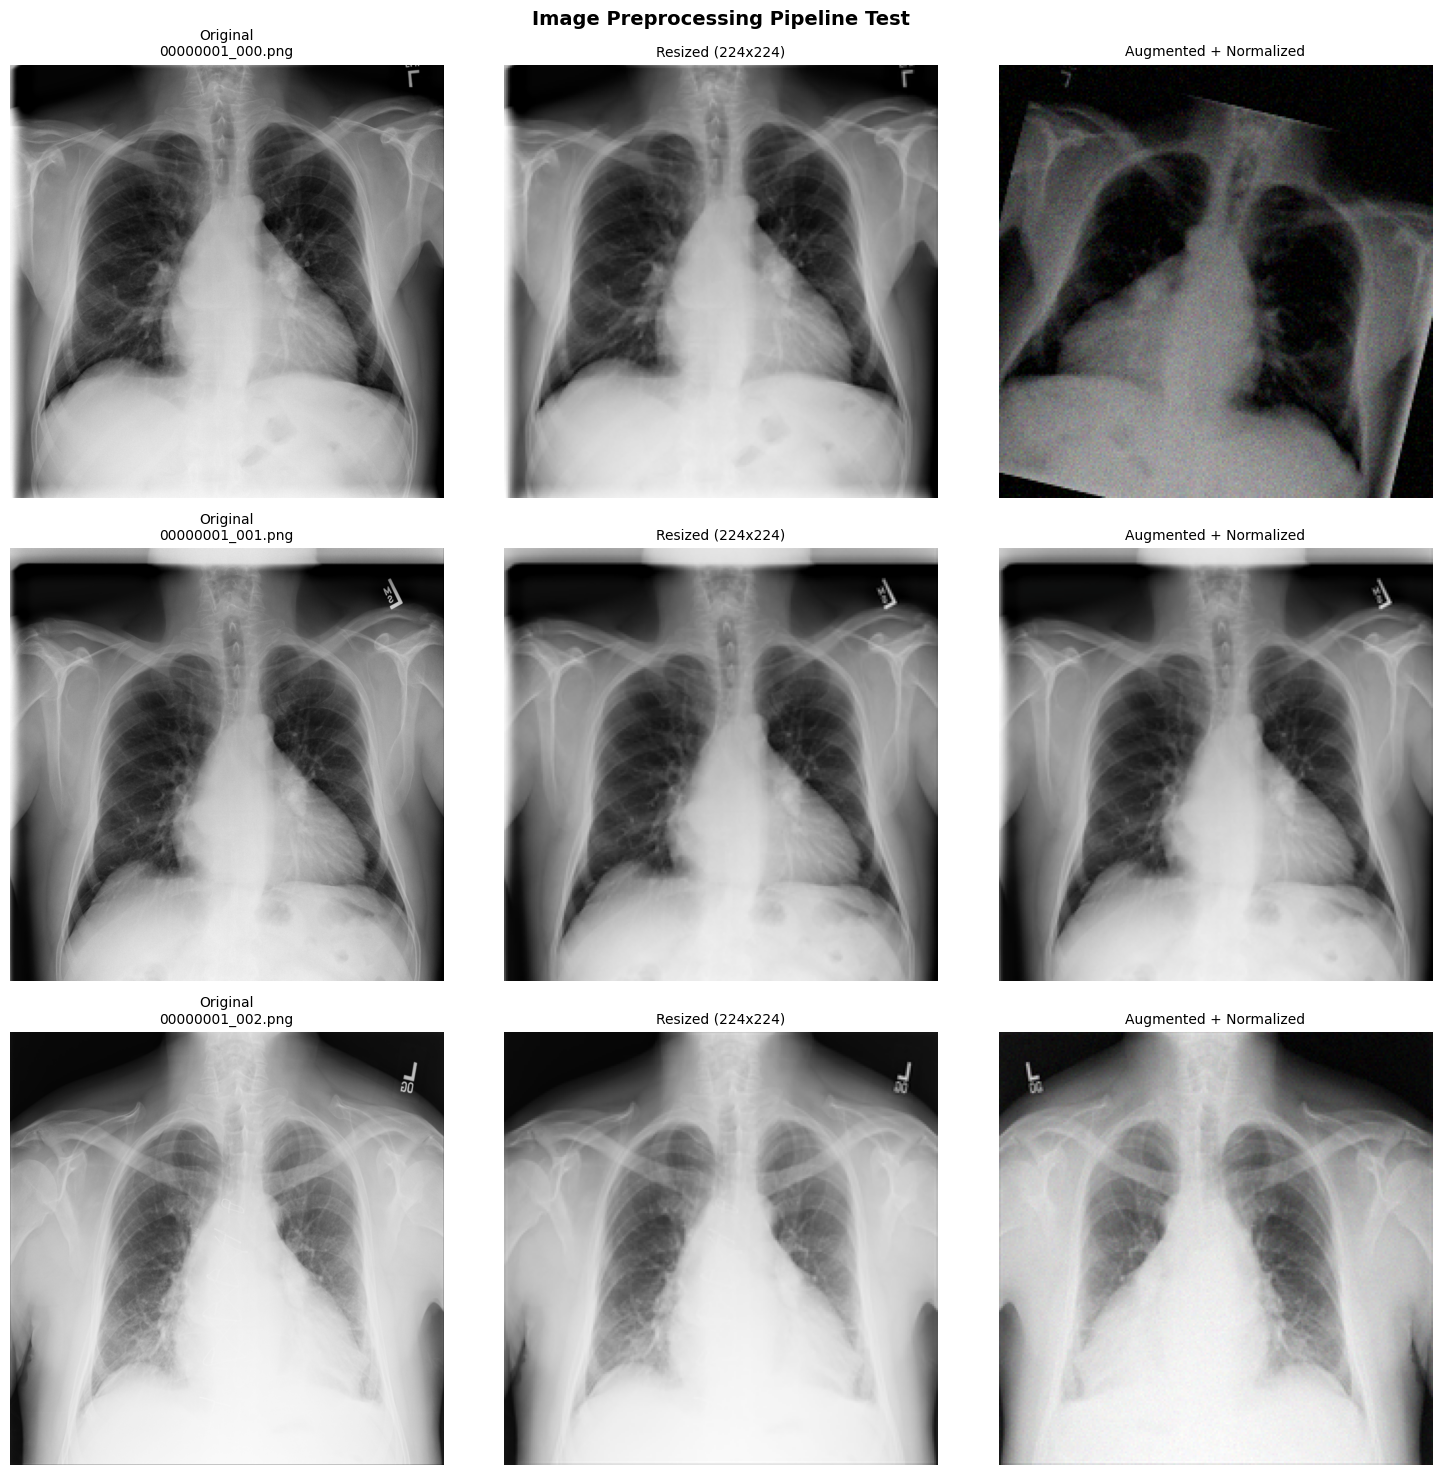

✓ Preprocessing pipeline tested successfully


In [15]:
# Test on a few sample images
sample_paths = train_df['full_path'].head(3).tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Determine resample filter for Pillow 10+ compatibility
if hasattr(Image, 'Resampling'):
    resample_filter = Image.Resampling.LANCZOS
else:
    resample_filter = Image.LANCZOS  # type: ignore

for i, img_path in enumerate(sample_paths):
    # Load original
    img_original = Image.open(img_path)
    if img_original.mode != 'RGB':
        img_original = img_original.convert('RGB')
    
    # Apply preprocessing without augmentation
    img_array_val = np.array(img_original.resize((224, 224), resample_filter))
    
    # Apply augmentation
    img_array_aug = train_transform(image=img_array_val)['image']
    
    # Display
    axes[i, 0].imshow(img_original, cmap='gray')
    axes[i, 0].set_title(f'Original\n{Path(img_path).name}', fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(img_array_val)
    axes[i, 1].set_title('Resized (224x224)', fontsize=10)
    axes[i, 1].axis('off')
    
    # Denormalize for visualization
    img_display = img_array_aug * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_display = np.clip(img_display, 0, 1)
    axes[i, 2].imshow(img_display)
    axes[i, 2].set_title('Augmented + Normalized', fontsize=10)
    axes[i, 2].axis('off')

plt.suptitle('Image Preprocessing Pipeline Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_preprocessing_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Preprocessing pipeline tested successfully")

## 10. Save Preprocessing Configuration

In [16]:
# Save complete preprocessing config
preprocessing_config = {
    'image_config': CONFIG,
    'disease_classes': disease_classes,
    'num_classes': len(disease_classes),
    'data_splits': {
        'train': {'patients': len(train_patients), 'images': len(train_df)},
        'val': {'patients': len(val_patients), 'images': len(val_df)},
        'test': {'patients': len(test_patients), 'images': len(test_df)}
    },
    'class_weights': class_weights_dict,
    'augmentation': {
        'horizontal_flip': True,
        'shift_scale_rotate': True,
        'brightness_contrast': True,
        'gaussian_noise': True
    }
}

with open(PROCESSED_DIR / 'preprocessing_config.json', 'w') as f:
    json.dump(preprocessing_config, f, indent=2)

print(f"✓ Saved preprocessing configuration to {PROCESSED_DIR / 'preprocessing_config.json'}")

✓ Saved preprocessing configuration to /Users/james/CodeInstitute/CapStone/data/processed/preprocessing_config.json


## 11. Summary

In [17]:
print("="*60)
print("  ✅ Notebook 03 Complete: Image Preprocessing")
print("="*60)

print("\n📊 Dataset Summary:")
print(f"  Total images: {len(metadata_df):,}")
print(f"  Disease classes: {len(disease_classes)}")
print(f"  Train: {len(train_df):,} images from {len(train_patients):,} patients")
print(f"  Val:   {len(val_df):,} images from {len(val_patients):,} patients")
print(f"  Test:  {len(test_df):,} images from {len(test_patients):,} patients")

print("\n🔧 Preprocessing Pipeline:")
print(f"  Image size: {CONFIG['img_height']}x{CONFIG['img_width']}x{CONFIG['channels']}")
print("  Normalization: ImageNet mean/std")
print("  Augmentation: Enabled for training")
print("  Class weights: Computed for imbalance")

print("\n📁 Generated Files:")
print(f"  {PROCESSED_DIR / 'train_split.csv'}")
print(f"  {PROCESSED_DIR / 'val_split.csv'}")
print(f"  {PROCESSED_DIR / 'test_split.csv'}")
print(f"  {PROCESSED_DIR / 'class_weights.json'}")
print(f"  {PROCESSED_DIR / 'preprocessing_config.json'}")

print("\n⏭️  Ready for Notebook 04: Baseline Models!")

  ✅ Notebook 03 Complete: Image Preprocessing

📊 Dataset Summary:
  Total images: 112,120
  Disease classes: 14
  Train: 78,566 images from 21,563 patients
  Val:   17,063 images from 4,621 patients
  Test:  16,491 images from 4,621 patients

🔧 Preprocessing Pipeline:
  Image size: 224x224x3
  Normalization: ImageNet mean/std
  Augmentation: Enabled for training
  Class weights: Computed for imbalance

📁 Generated Files:
  /Users/james/CodeInstitute/CapStone/data/processed/train_split.csv
  /Users/james/CodeInstitute/CapStone/data/processed/val_split.csv
  /Users/james/CodeInstitute/CapStone/data/processed/test_split.csv
  /Users/james/CodeInstitute/CapStone/data/processed/class_weights.json
  /Users/james/CodeInstitute/CapStone/data/processed/preprocessing_config.json

⏭️  Ready for Notebook 04: Baseline Models!
